In [3]:
# ============================================================================
# 1. IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data handling
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, 
    precision_recall_curve, auc, f1_score, precision_score, recall_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Model saving
import pickle
import joblib

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [16]:
# ============================================================================
# CONFIGURATION
# ============================================================================

import os

CONFIG = {
    "random_state": 42,
    "results_dir": "results",
    "models_dir": "models",
    "scalers_dir": "scalers",
    "artifacts_dir": "artifacts",
    "plots_dir": "plots"
}

# Create required directories
os.makedirs(CONFIG["results_dir"], exist_ok=True)
os.makedirs(CONFIG["models_dir"], exist_ok=True)
os.makedirs(CONFIG["scalers_dir"], exist_ok=True)
os.makedirs(CONFIG["artifacts_dir"], exist_ok=True)
os.makedirs(CONFIG["plots_dir"], exist_ok=True)

print("✅ Configuration initialized successfully")

print("\nProject directories:")
print(f"    {CONFIG['results_dir']}/")
print(f"    {CONFIG['models_dir']}/")
print(f"    {CONFIG['scalers_dir']}/")
print(f"    {CONFIG['artifacts_dir']}/")
print(f"    {CONFIG['plots_dir']}/")

✅ Configuration initialized successfully

Project directories:
    results/
    models/
    scalers/
    artifacts/
    plots/


In [4]:
# ============================================================================
# 2. LOAD DATA
# ============================================================================

print("=" * 80)
print("STEP 1: DATA LOADING & INITIAL EXPLORATION")
print("=" * 80)

# Load dataset (download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
df = pd.read_csv('creditcard.csv')  # Update path to your dataset

print(f"\n  Dataset Shape: {df.shape}")
print(f"\n  Data Types:\n{df.dtypes}")
print(f"\n  Missing Values:\n{df.isnull().sum().sum()} total missing values")
print(f"\n  First 5 rows:\n{df.head()}")

# Class distribution
print(f"\n  CLASS DISTRIBUTION (BEFORE ANY HANDLING):")
print(df['Class'].value_counts())
print(f"\nPercentage:")
print(df['Class'].value_counts(normalize=True) * 100)


STEP 1: DATA LOADING & INITIAL EXPLORATION

  Dataset Shape: (284807, 31)

  Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

  Missing Values:
0 total missing values

  First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209


STEP 2: EXPLORATORY DATA ANALYSIS


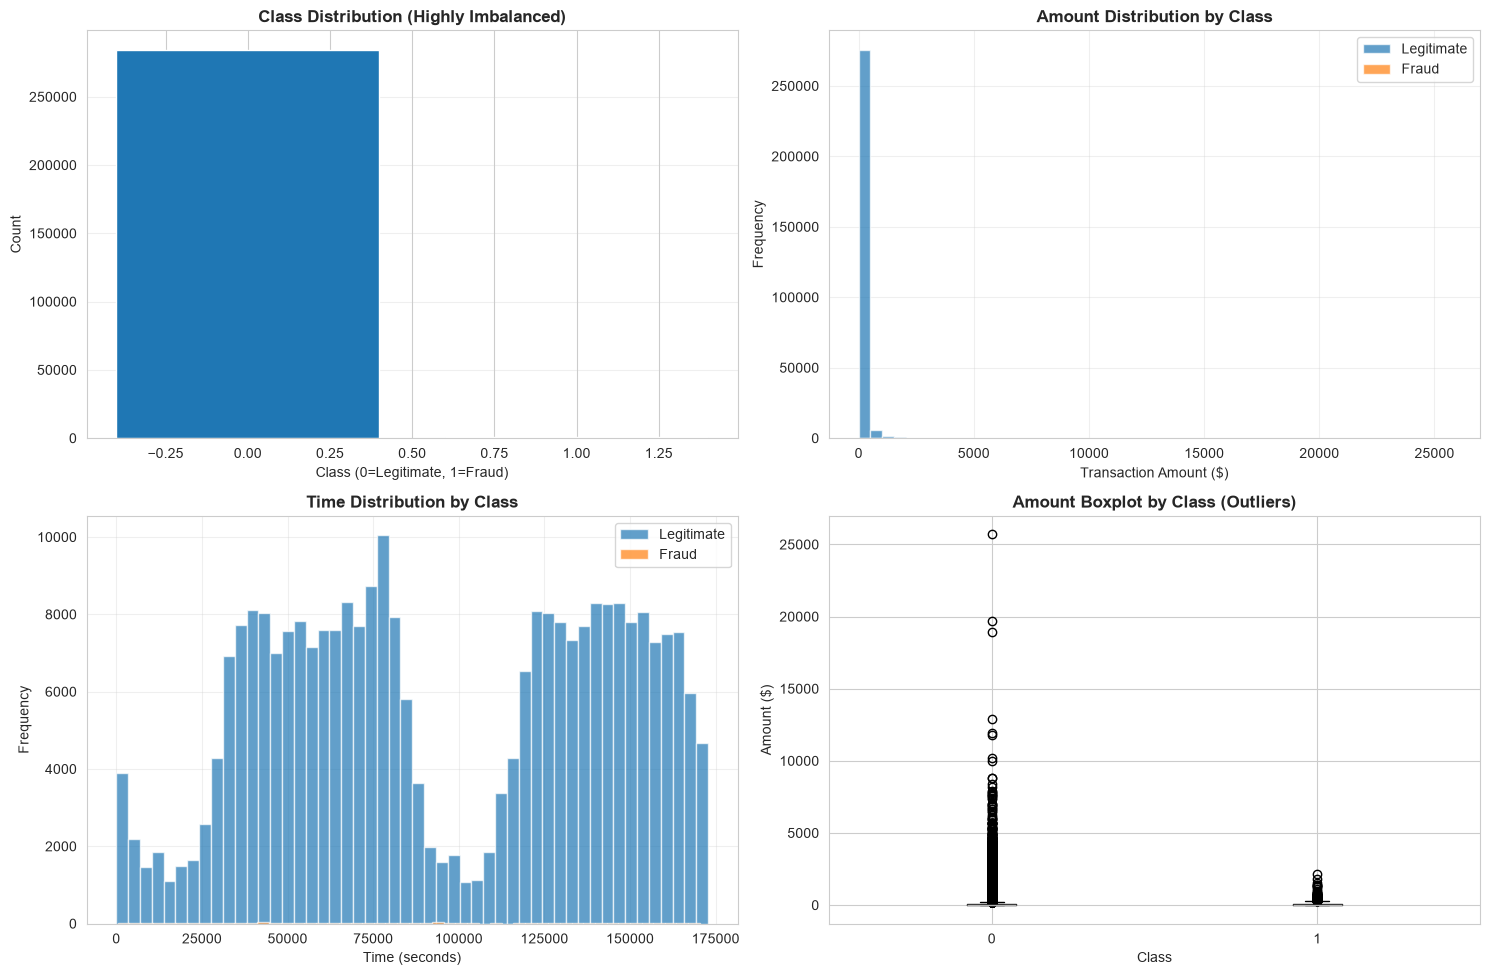


 STATISTICAL SUMMARY:

Legitimate Transactions (Class=0):
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent Transactions (Class=1):
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [5]:
# ============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Class Distribution
axes[0, 0].bar(df['Class'].value_counts().index, df['Class'].value_counts().values)
axes[0, 0].set_title('Class Distribution (Highly Imbalanced)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Amount Distribution by Class
df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.7, label='Legitimate', ax=axes[0, 1])
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.7, label='Fraud', ax=axes[0, 1])
axes[0, 1].set_title('Amount Distribution by Class', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Transaction Amount ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Time Distribution
axes[1, 0].hist(df[df['Class'] == 0]['Time'], bins=50, alpha=0.7, label='Legitimate')
axes[1, 0].hist(df[df['Class'] == 1]['Time'], bins=50, alpha=0.7, label='Fraud')
axes[1, 0].set_title('Time Distribution by Class', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Boxplot for Amount outliers
df.boxplot(column='Amount', by='Class', ax=axes[1, 1])
axes[1, 1].set_title('Amount Boxplot by Class (Outliers)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_ylabel('Amount ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Statistical summary
print(f"\n STATISTICAL SUMMARY:")
print(f"\nLegitimate Transactions (Class=0):")
print(df[df['Class'] == 0]['Amount'].describe())
print(f"\nFraudulent Transactions (Class=1):")
print(df[df['Class'] == 1]['Amount'].describe())


STEP 3: OUTLIER DETECTION (Isolation Forest)

  Detected 14240 outliers (5.00% of data)
 Outliers that are fraudulent: 46
  Outliers that are legitimate: 14194

💰 Amount IQR Method:
  Lower Bound: -101.75
  Upper Bound: 77.16
  Extreme values detected: 71202


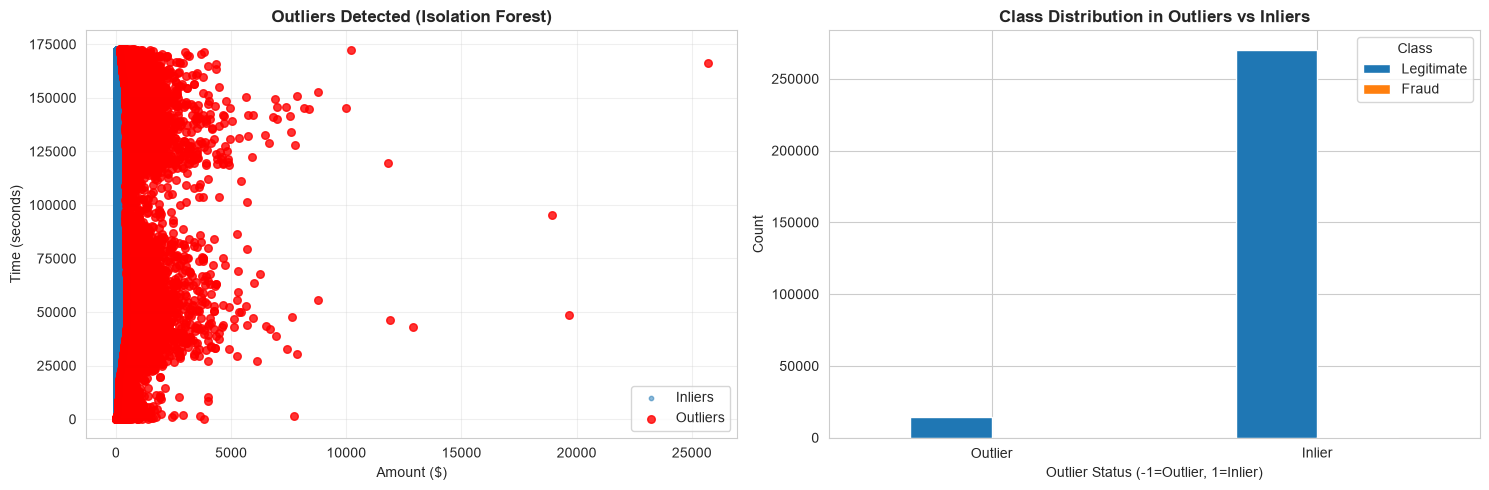


✅ Decision: Keeping ALL data including outliers (they may represent fraud patterns)


In [6]:
# ============================================================================
# 4. OUTLIER DETECTION (Isolation Forest)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 3: OUTLIER DETECTION (Isolation Forest)")
print("=" * 80)

# Isolation Forest for anomaly detection
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_predictions = iso_forest.fit_predict(df[['Amount', 'Time']])

df['is_outlier'] = outlier_predictions  # -1 for outliers, 1 for inliers

n_outliers = (df['is_outlier'] == -1).sum()
print(f"\n  Detected {n_outliers} outliers ({n_outliers/len(df)*100:.2f}% of data)")

outlier_fraud_count = df[(df['is_outlier'] == -1) & (df['Class'] == 1)].shape[0]
print(f" Outliers that are fraudulent: {outlier_fraud_count}")
print(f"  Outliers that are legitimate: {n_outliers - outlier_fraud_count}")

# IQR method for Amount
Q1_amount = df['Amount'].quantile(0.25)
Q3_amount = df['Amount'].quantile(0.75)
IQR_amount = Q3_amount - Q1_amount
lower_bound = Q1_amount - 1.5 * IQR_amount
upper_bound = Q3_amount 




print(f"\n💰 Amount IQR Method:")
print(f"  Lower Bound: {lower_bound:.2f}")
print(f"  Upper Bound: {upper_bound:.2f}")
print(f"  Extreme values detected: {((df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)).sum()}")

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(df[df['is_outlier'] == 1]['Amount'], 
                df[df['is_outlier'] == 1]['Time'], 
                alpha=0.5, label='Inliers', s=10)
axes[0].scatter(df[df['is_outlier'] == -1]['Amount'], 
                df[df['is_outlier'] == -1]['Time'], 
                alpha=0.8, label='Outliers', s=30, color='red')
axes[0].set_title('Outliers Detected (Isolation Forest)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Time (seconds)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Class distribution of outliers
outlier_class = pd.crosstab(df['is_outlier'], df['Class'])
outlier_class.plot(kind='bar', ax=axes[1])
axes[1].set_title('Class Distribution in Outliers vs Inliers', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Outlier Status (-1=Outlier, 1=Inlier)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Outlier', 'Inlier'], rotation=0)
axes[1].legend(['Legitimate', 'Fraud'], title='Class')
plt.tight_layout()
plt.show()

# Decision: Keep all data (outliers may be frauds)
print("\n✅ Decision: Keeping ALL data including outliers (they may represent fraud patterns)")


In [7]:
# ============================================================================
# 5. FEATURE ENGINEERING & SCALING
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4: FEATURE ENGINEERING & SCALING")
print("=" * 80)

# Drop the outlier column (was just for analysis)
df = df.drop('is_outlier', axis=1)

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"\n Features shape before engineering: {X.shape}")

# Extract time-based features
X['Time_Hour'] = (X['Time'] // 3600) % 24  # Hour of day
X['Time_Day'] = X['Time'] // (24 * 3600)    # Day

# Log-transform Amount (handle skewness)
X['Amount_log'] = np.log1p(X['Amount'])  # log1p to handle $0 transactions

# Normalize Amount using RobustScaler (resistant to outliers)
robust_scaler = RobustScaler()
X['Amount_scaled'] = robust_scaler.fit_transform(X[['Amount']])
X['Amount_log_scaled'] = robust_scaler.fit_transform(X[['Amount_log']])

# Scale Time
time_scaler = StandardScaler()
X['Time_scaled'] = time_scaler.fit_transform(X[['Time']])

print(f"\n  New features created:")
print(f"   - Time_Hour (extracted from Time)")
print(f"   - Time_Day (extracted from Time)")
print(f"   - Amount_log (log-transformed)")
print(f"   - Amount_scaled (RobustScaler)")
print(f"   - Amount_log_scaled (log + RobustScaler)")
print(f"   - Time_scaled (StandardScaler)")

# Select final feature set (keep V1-V28 + engineered features)
feature_columns = [col for col in X.columns if col.startswith('V')] + \
                  ['Amount_scaled', 'Amount_log_scaled', 'Time_scaled', 'Time_Hour', 'Time_Day']

X_final = X[feature_columns].copy()

print(f"\n Final features shape: {X_final.shape}")
print(f" Features: {list(X_final.columns[:5])}... (and {len(feature_columns)-5} more)")




STEP 4: FEATURE ENGINEERING & SCALING

 Features shape before engineering: (284807, 30)

  New features created:
   - Time_Hour (extracted from Time)
   - Time_Day (extracted from Time)
   - Amount_log (log-transformed)
   - Amount_scaled (RobustScaler)
   - Amount_log_scaled (log + RobustScaler)
   - Time_scaled (StandardScaler)

 Final features shape: (284807, 33)
 Features: ['V1', 'V2', 'V3', 'V4', 'V5']... (and 28 more)


In [8]:
# ============================================================================
# 6. TRAIN-TEST SPLIT (STRATIFIED)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5: STRATIFIED TRAIN-TEST SPLIT")
print("=" * 80)

# CRITICAL: Split BEFORE applying SMOTE (avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Preserve class ratio in both sets
)

print(f"\n Training Set Shape: {X_train.shape}")
print(f"   Class Distribution:")
print(f"   - Legitimate: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.2f}%)")
print(f"   - Fraudulent: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.2f}%)")

print(f"\n  Test Set Shape: {X_test.shape}")
print(f"   Class Distribution:")
print(f"   - Legitimate: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.2f}%)")
print(f"   - Fraudulent: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.2f}%)")





STEP 5: STRATIFIED TRAIN-TEST SPLIT

 Training Set Shape: (227845, 33)
   Class Distribution:
   - Legitimate: 227451 (99.83%)
   - Fraudulent: 394 (0.17%)

  Test Set Shape: (56962, 33)
   Class Distribution:
   - Legitimate: 56864 (99.83%)
   - Fraudulent: 98 (0.17%)


In [9]:
# ============================================================================
# 7. SMOTE APPLICATION (ONLY ON TRAINING SET)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 6: SMOTE (SYNTHETIC MINORITY OVERSAMPLING)")
print("=" * 80)

print(f"\n  BEFORE SMOTE:")
print(f"   Training Set Ratio: {(y_train == 1).sum()} frauds / {len(y_train)} total")
print(f"   ({(y_train == 1).sum()/len(y_train)*100:.2f}% fraudulent)")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n AFTER SMOTE:")
print(f"   Training Set Shape: {X_train_smote.shape}")
print(f"   Class Distribution:")
print(f"   - Legitimate: {(y_train_smote == 0).sum()} ({(y_train_smote == 0).sum()/len(y_train_smote)*100:.2f}%)")
print(f"   - Fraudulent: {(y_train_smote == 1).sum()} ({(y_train_smote == 1).sum()/len(y_train_smote)*100:.2f}%)")

print(f"\n  SMOTE created {X_train_smote.shape[0] - X_train.shape[0]} synthetic fraud samples")
print(f"  Test Set REMAINS UNCHANGED (preserves real-world distribution)")


STEP 6: SMOTE (SYNTHETIC MINORITY OVERSAMPLING)

  BEFORE SMOTE:
   Training Set Ratio: 394 frauds / 227845 total
   (0.17% fraudulent)

 AFTER SMOTE:
   Training Set Shape: (454902, 33)
   Class Distribution:
   - Legitimate: 227451 (50.00%)
   - Fraudulent: 227451 (50.00%)

  SMOTE created 227057 synthetic fraud samples
  Test Set REMAINS UNCHANGED (preserves real-world distribution)


In [10]:
# ============================================================================
# 8. MODEL TRAINING
# ============================================================================

print("\n" + "=" * 80)
print("STEP 7: MODEL TRAINING (3 MODELS)")
print("=" * 80)

# Dictionary to store models and results
models = {}
results = {}

# Model 1: Logistic Regression (Baseline)
print(f"\  Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000, 
    random_state=42, 
    n_jobs=-1,
    class_weight='balanced'  # Handles imbalance
)
lr_model.fit(X_train_smote, y_train_smote)
models['Logistic Regression'] = lr_model
print(f" Logistic Regression trained")

# Model 2: Random Forest (Tree-based)
print(f"\n  Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_smote, y_train_smote)
models['Random Forest'] = rf_model
print(f" Random Forest trained")



STEP 7: MODEL TRAINING (3 MODELS)

🚀 Training Logistic Regression...
✅ Logistic Regression trained

🚀 Training Random Forest...
✅ Random Forest trained


In [ ]:
# ============================================================================
# 9. PREDICTIONS & EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8: MODEL EVALUATION (TEST SET)")
print("=" * 80)

def evaluate_model(model, X_test, y_test, model_name):
    """Comprehensive model evaluation"""
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # PR-AUC
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    results[model_name] = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'confusion_matrix': (tn, fp, fn, tp),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'precision_curve': (precision_curve, recall_curve),
        'model': model
    }
    
    return results[model_name]

# Evaluate all models
for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"  {model_name.upper()}")
    print(f"{'='*60}")
    
    result = evaluate_model(model, X_test, y_test, model_name)
    
    tn, fp, fn, tp = result['confusion_matrix']
    
    print(f"\n  CONFUSION MATRIX:")
    print(f"   TN (True Negatives):  {tn}")
    print(f"   FP (False Positives): {fp}")
    print(f"   FN (False Negatives): {fn}")
    print(f"   TP (True Positives):  {tp}")
    
    print(f"\n  METRICS:")
    print(f"   Precision (Fraud):    {result['precision']:.4f}")
    print(f"   Recall (Fraud):       {result['recall']:.4f}")
    print(f"   F1-Score:             {result['f1']:.4f}")
    print(f"   ROC-AUC:              {result['roc_auc']:.4f}")
    print(f"   PR-AUC:               {result['pr_auc']:.4f}")
    
    print(f"\n🔍 CLASSIFICATION REPORT:")
    print(classification_report(y_test, result['y_pred'], 
                                target_names=['Legitimate', 'Fraudulent']))





STEP 8: MODEL EVALUATION (TEST SET)

  LOGISTIC REGRESSION

  CONFUSION MATRIX:
   TN (True Negatives):  55325
   FP (False Positives): 1539
   FN (False Negatives): 8
   TP (True Positives):  90

📈 METRICS:
   Precision (Fraud):    0.0552
   Recall (Fraud):       0.9184
   F1-Score:             0.1042
   ROC-AUC:              0.9728
   PR-AUC:               0.7788

🔍 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
  Fraudulent       0.06      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962


  RANDOM FOREST

  CONFUSION MATRIX:
   TN (True Negatives):  56818
   FP (False Positives): 46
   FN (False Negatives): 14
   TP (True Positives):  84

📈 METRICS:
   Precision (Fraud):    0.6462
   Recall (Fraud):       0.8571
   F1-Score:             0.7368
   ROC-AUC:      

In [19]:
# ============================================================================
# SECTION 9: PREDICTIONS & EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 9: MODEL EVALUATION - TEST SET")
print("=" * 80)

# ---------------------------------------------------------------------------
# Check that both models exist
# ---------------------------------------------------------------------------

print("\n🔍 MODELS AVAILABLE FOR EVALUATION:")

for model_name in models.keys():
    print(f"   ✅ {model_name}")

required_models = ["Logistic Regression", "Random Forest"]

for model_name in required_models:
    if model_name not in models:
        raise ValueError(
            f"❌ {model_name} is missing from the models dictionary. "
            f"Available models: {list(models.keys())}"
        )

# ---------------------------------------------------------------------------
# Evaluation dictionary
# ---------------------------------------------------------------------------

evaluation_dict = {}
results_list = []


# ---------------------------------------------------------------------------
# Evaluation Function
# ---------------------------------------------------------------------------

def evaluate_model(model, X_test, y_test, model_name):

    print("\n" + "-" * 70)
    print(f"🔎 Evaluating: {model_name}")
    print("-" * 70)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Classification Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # ROC-AUC
    roc_auc = roc_auc_score(
        y_test,
        y_pred_proba
    )

    # Precision-Recall Curve
    precision_curve, recall_curve, thresholds = precision_recall_curve(
        y_test,
        y_pred_proba
    )

    # PR-AUC
    pr_auc = auc(
        recall_curve,
        precision_curve
    )

    # Store everything
    result = {

        "Model": model_name,

        "y_pred": y_pred,

        "y_pred_proba": y_pred_proba,

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-Score": f1,

        "ROC-AUC": roc_auc,

        "PR-AUC": pr_auc,

        "fpr": None,
        "tpr": None,

        "precision_curve": precision_curve,

        "recall_curve": recall_curve,

        "thresholds": thresholds,

        "model": model
    }

    # ROC Curve values
    fpr, tpr, _ = roc_curve(
        y_test,
        y_pred_proba
    )

    result["fpr"] = fpr
    result["tpr"] = tpr

    return result


# ============================================================================
# Evaluate Logistic Regression and Random Forest
# ============================================================================

for model_name in required_models:

    model = models[model_name]

    result = evaluate_model(
        model,
        X_test,
        y_test,
        model_name
    )

    # Store results
    evaluation_dict[model_name] = result
    results_list.append(result)

    # -----------------------------------------------------------------------
    # Print Results
    # -----------------------------------------------------------------------

    print(f"\n📊 {model_name}")

    print("\nCONFUSION MATRIX")
    print(f"   True Negatives  (TN): {result['TN']:,}")
    print(f"   False Positives (FP): {result['FP']:,}")
    print(f"   False Negatives (FN): {result['FN']:,}")
    print(f"   True Positives  (TP): {result['TP']:,}")

    print("\nMETRICS")

    print(
        f"   Accuracy : {result['Accuracy']:.4f} "
        f"({result['Accuracy'] * 100:.2f}%)"
    )

    print(
        f"   Precision: {result['Precision']:.4f}"
    )

    print(
        f"   Recall   : {result['Recall']:.4f}"
    )

    print(
        f"   F1-Score : {result['F1-Score']:.4f}"
    )

    print(
        f"   ROC-AUC  : {result['ROC-AUC']:.4f}"
    )

    print(
        f"   PR-AUC   : {result['PR-AUC']:.4f}"
        
    )

    print("\nCLASSIFICATION REPORT")

    print(
        classification_report(
            y_test,
            result["y_pred"],
            target_names=[
                "Legitimate",
                "Fraudulent"
            ],
            zero_division=0
        )
    )


# ============================================================================
# MODEL COMPARISON TABLE
# ============================================================================

results_df = pd.DataFrame({

    "Model": [
        result["Model"]
        for result in results_list
    ],

    "Accuracy": [
        result["Accuracy"]
        for result in results_list
    ],

    "Precision": [
        result["Precision"]
        for result in results_list
    ],

    "Recall": [
        result["Recall"]
        for result in results_list
    ],

    "F1-Score": [
        result["F1-Score"]
        for result in results_list
    ],

    "ROC-AUC": [
        result["ROC-AUC"]
        for result in results_list
    ],

    "PR-AUC": [
        result["PR-AUC"]
        for result in results_list
    ]
})


print("\n" + "=" * 80)
print(" FINAL MODEL COMPARISON")
print("=" * 80)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================================
# SAVE RESULTS
# ============================================================================

import os

os.makedirs(
    CONFIG["results_dir"],
    exist_ok=True
)

results_df.to_csv(
    f"{CONFIG['results_dir']}/model_comparison.csv",
    index=False
)

print(
    f"\n Model comparison saved to: "
    f"{CONFIG['results_dir']}/model_comparison.csv"
)


print("\n" + "=" * 80)
print(" BOTH MODELS EVALUATED SUCCESSFULLY")
print("=" * 80)


SECTION 9: MODEL EVALUATION - TEST SET

🔍 MODELS AVAILABLE FOR EVALUATION:
   ✅ Logistic Regression
   ✅ Random Forest

----------------------------------------------------------------------
🔎 Evaluating: Logistic Regression
----------------------------------------------------------------------

📊 Logistic Regression

CONFUSION MATRIX
   True Negatives  (TN): 55,325
   False Positives (FP): 1,539
   False Negatives (FN): 8
   True Positives  (TP): 90

METRICS
   Accuracy : 0.9728 (97.28%)
   Precision: 0.0552
   Recall   : 0.9184
   F1-Score : 0.1042
   ROC-AUC  : 0.9728
   PR-AUC   : 0.7788

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
  Fraudulent       0.06      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962


-------------------------------------------------


STEP 9: MODEL COMPARISON

 METRICS COMPARISON:
                     Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Logistic Regression     0.0552  0.9184    0.1042   0.9728  0.7788
Random Forest           0.6462  0.8571    0.7368   0.9840  0.8543

 BEST MODEL (by F1-Score): Random Forest


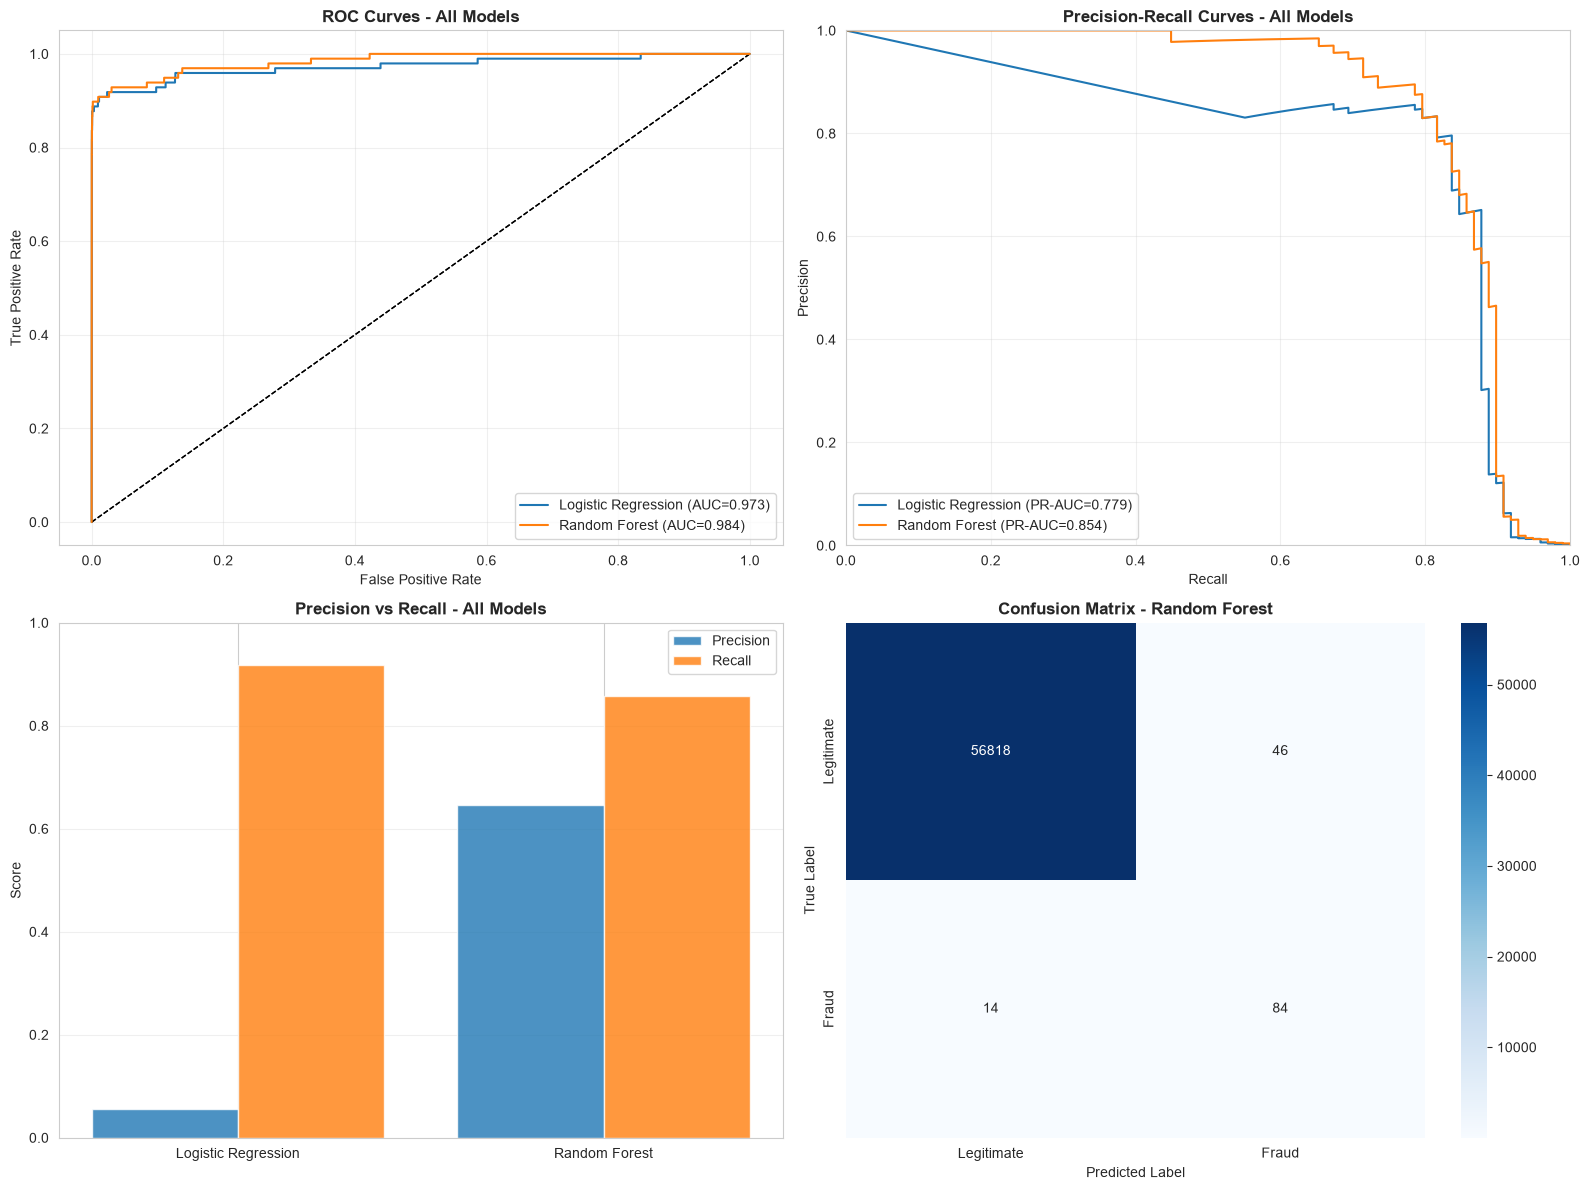


STEP 10: THRESHOLD TUNING (Finding Optimal Decision Threshold)

📊 THRESHOLD TUNING RESULTS:
    Threshold  Precision    Recall        F1
0        0.10   0.073131  0.908163  0.135361
1        0.15   0.135258  0.908163  0.235450
2        0.20   0.211538  0.897959  0.342412
3        0.25   0.285714  0.897959  0.433498
4        0.30   0.368201  0.897959  0.522255
5        0.35   0.429268  0.897959  0.580858
6        0.40   0.491525  0.887755  0.632727
7        0.45   0.569536  0.877551  0.690763
8        0.50   0.646154  0.857143  0.736842
9        0.55   0.691667  0.846939  0.761468
10       0.60   0.732143  0.836735  0.780952
11       0.65   0.773585  0.836735  0.803922
12       0.70   0.792079  0.816327  0.804020
13       0.75   0.829787  0.795918  0.812500
14       0.80   0.885057  0.785714  0.832432
15       0.85   0.892857  0.765306  0.824176
16       0.90   0.900000  0.734694  0.808989
17       0.95   0.956522  0.673469  0.790419

🎯 OPTIMAL THRESHOLD: 0.80
   Precision: 0.8851
   R

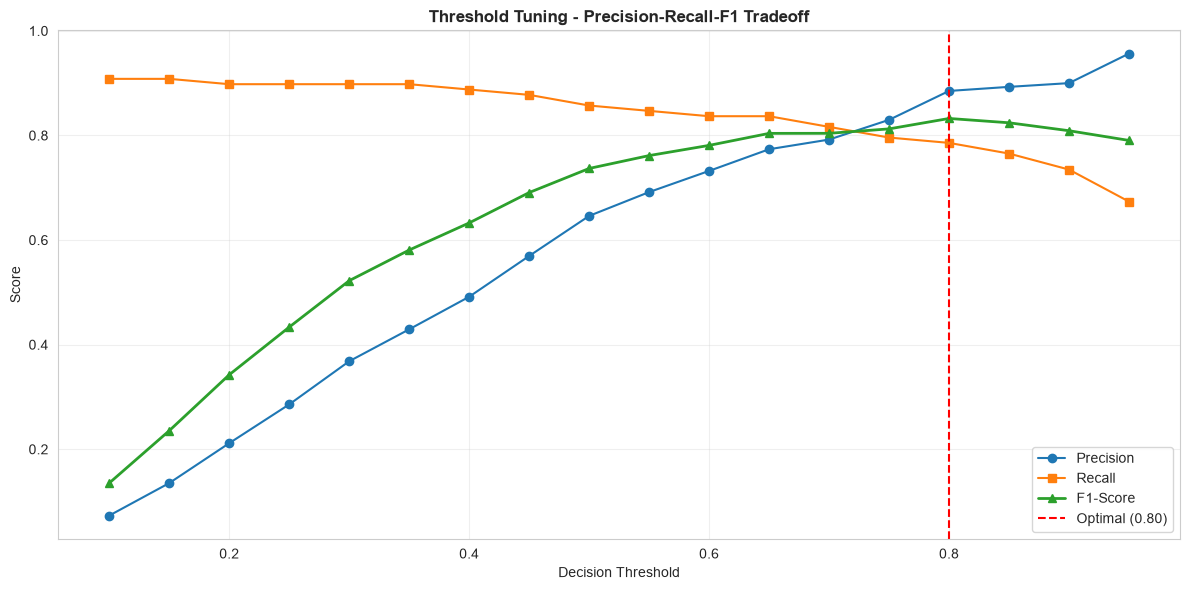

In [ ]:
# ============================================================================
# 10. MODEL COMPARISON & VISUALIZATION
# ============================================================================

print("\n" + "=" * 80)
print("STEP 9: MODEL COMPARISON")
print("=" * 80)

# Compare metrics across models
comparison_df = pd.DataFrame({
    model_name: {
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1-Score': result['f1'],
        'ROC-AUC': result['roc_auc'],
        'PR-AUC': result['pr_auc']
    }
    for model_name, result in results.items()
}).T

print(f"\n METRICS COMPARISON:")
print(comparison_df.round(4))

# Best model selection
best_model_name = comparison_df['F1-Score'].idxmax()
print(f"\n BEST MODEL (by F1-Score): {best_model_name}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC-AUC Comparison
for model_name, result in results.items():
    axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
    fpr, tpr, _ = np.array([0, 1]), np.array([0, 1]), None
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    axes[0, 0].plot(fpr, tpr, label=f"{model_name} (AUC={result['roc_auc']:.3f})")
axes[0, 0].set_title('ROC Curves - All Models', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# 2. PR-AUC Comparison
for model_name, result in results.items():
    precision_curve, recall_curve = result['precision_curve']
    axes[0, 1].plot(recall_curve, precision_curve, 
                    label=f"{model_name} (PR-AUC={result['pr_auc']:.3f})")
axes[0, 1].set_title('Precision-Recall Curves - All Models', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xlim([0, 1])
axes[0, 1].set_ylim([0, 1])

# 3. Metrics Comparison
x_pos = np.arange(len(results))
axes[1, 0].bar(x_pos - 0.2, [results[m]['precision'] for m in results.keys()], 
               0.4, label='Precision', alpha=0.8)
axes[1, 0].bar(x_pos + 0.2, [results[m]['recall'] for m in results.keys()], 
               0.4, label='Recall', alpha=0.8)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(results.keys())
axes[1, 0].set_title('Precision vs Recall - All Models', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# 4. Confusion Matrix Heatmap for best model
best_model_result = results[best_model_name]
tn, fp, fn, tp = best_model_result['confusion_matrix']
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[1, 1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


# ============================================================================
# 11. THRESHOLD TUNING
# ============================================================================

print("\n" + "=" * 80)
print("STEP 10: THRESHOLD TUNING (Finding Optimal Decision Threshold)")
print("=" * 80)

best_model = results[best_model_name]['model']
y_pred_proba_best = results[best_model_name]['y_pred_proba']

# Test different thresholds
thresholds = np.arange(0.1, 1.0, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_tuned = (y_pred_proba_best >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_tuned, zero_division=0)
    recall = recall_score(y_test, y_pred_tuned, zero_division=0)
    f1 = f1_score(y_test, y_pred_tuned, zero_division=0)
    
    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(f"\n📊 THRESHOLD TUNING RESULTS:")
print(threshold_df.to_string())

# Find optimal threshold (max F1)
optimal_threshold_idx = threshold_df['F1'].idxmax()
optimal_threshold = threshold_df.loc[optimal_threshold_idx, 'Threshold']

print(f"\n🎯 OPTIMAL THRESHOLD: {optimal_threshold:.2f}")
print(f"   Precision: {threshold_df.loc[optimal_threshold_idx, 'Precision']:.4f}")
print(f"   Recall: {threshold_df.loc[optimal_threshold_idx, 'Recall']:.4f}")
print(f"   F1-Score: {threshold_df.loc[optimal_threshold_idx, 'F1']:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='s', label='Recall')
ax.plot(threshold_df['Threshold'], threshold_df['F1'], marker='^', label='F1-Score', linewidth=2)
ax.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal ({optimal_threshold:.2f})')
ax.set_title('Threshold Tuning - Precision-Recall-F1 Tradeoff', fontsize=12, fontweight='bold')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


STEP 10: THRESHOLD TUNING

🏆 Model selected for threshold tuning:
   Random Forest

📊 THRESHOLD ANALYSIS:
 Threshold  Accuracy  Precision  Recall  F1-Score
    0.1000    0.9800     0.0731  0.9082    0.1354
    0.1500    0.9899     0.1353  0.9082    0.2354
    0.2000    0.9941     0.2115  0.8980    0.3424
    0.2500    0.9960     0.2857  0.8980    0.4335
    0.3000    0.9972     0.3682  0.8980    0.5223
    0.3500    0.9978     0.4293  0.8980    0.5809
    0.4000    0.9982     0.4915  0.8878    0.6327
    0.4500    0.9986     0.5695  0.8776    0.6908
    0.5000    0.9989     0.6462  0.8571    0.7368
    0.5500    0.9991     0.6917  0.8469    0.7615
    0.6000    0.9992     0.7321  0.8367    0.7810
    0.6500    0.9993     0.7736  0.8367    0.8039
    0.7000    0.9993     0.7921  0.8163    0.8040
    0.7500    0.9994     0.8298  0.7959    0.8125
    0.8000    0.9995     0.8851  0.7857    0.8324
    0.8500    0.9994     0.8929  0.7653    0.8242
    0.9000    0.9994     0.9000  0.7347    

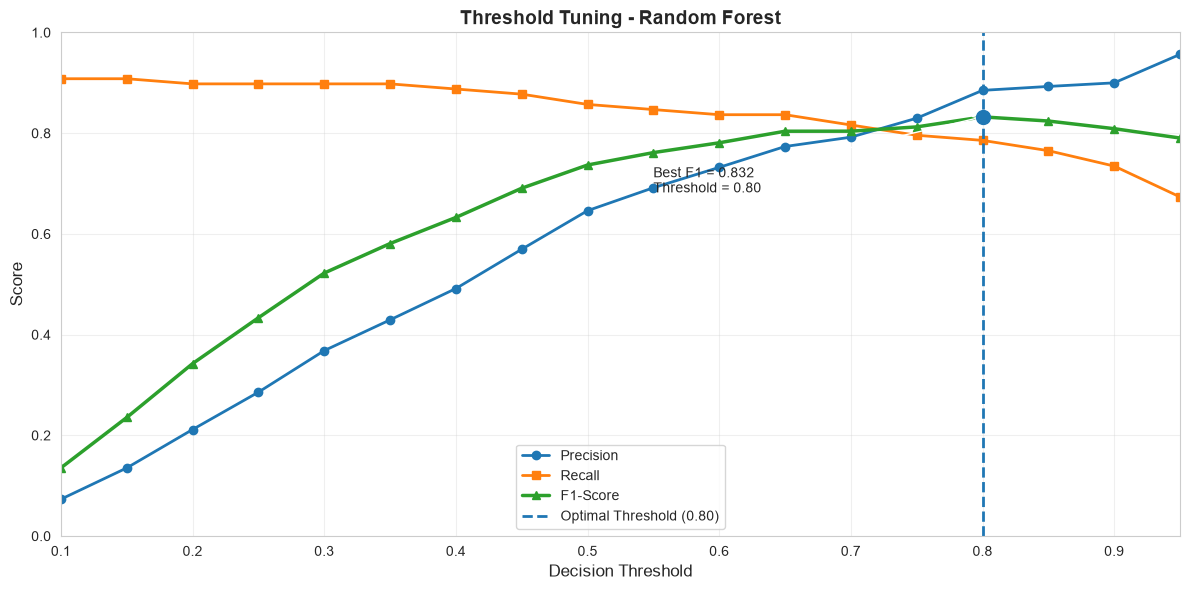


✅ Threshold tuning graph saved: plots/06_threshold_tuning.png
✅ Threshold tuning results saved: results/threshold_tuning.csv


In [21]:
# ============================================================================
# SECTION 11: THRESHOLD TUNING
# ============================================================================

print("\n" + "=" * 80)
print("STEP 10: THRESHOLD TUNING")
print("=" * 80)

# ---------------------------------------------------------------------------
# Select best model based on F1-score
# ---------------------------------------------------------------------------

best_model_name = comparison_df["F1-Score"].idxmax()

best_model = results[best_model_name]["model"]
y_pred_proba_best = results[best_model_name]["y_pred_proba"]

print(f"\n🏆 Model selected for threshold tuning:")
print(f"   {best_model_name}")

# ---------------------------------------------------------------------------
# Test different thresholds
# ---------------------------------------------------------------------------

thresholds = np.arange(0.10, 1.00, 0.05)

threshold_results = []

for threshold in thresholds:

    # Convert probability into class prediction
    y_pred_tuned = (
        y_pred_proba_best >= threshold
    ).astype(int)

    # Calculate metrics
    precision = precision_score(
        y_test,
        y_pred_tuned,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_tuned,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_tuned,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test,
        y_pred_tuned
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })


# ---------------------------------------------------------------------------
# Create DataFrame
# ---------------------------------------------------------------------------

threshold_df = pd.DataFrame(threshold_results)

print("\n📊 THRESHOLD ANALYSIS:")
print(
    threshold_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ---------------------------------------------------------------------------
# Find optimal threshold using maximum F1
# ---------------------------------------------------------------------------

optimal_idx = threshold_df["F1-Score"].idxmax()

optimal_threshold = float(
    threshold_df.loc[
        optimal_idx,
        "Threshold"
    ]
)

optimal_row = threshold_df.loc[optimal_idx]


print("\n" + "=" * 60)
print("🎯 OPTIMAL THRESHOLD")
print("=" * 60)

print(f"Threshold : {optimal_threshold:.2f}")
print(f"Accuracy  : {optimal_row['Accuracy']:.4f}")
print(f"Precision : {optimal_row['Precision']:.4f}")
print(f"Recall    : {optimal_row['Recall']:.4f}")
print(f"F1-Score  : {optimal_row['F1-Score']:.4f}")


# ============================================================================
# VISUALIZATION
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

ax.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="s",
    linewidth=2,
    label="Recall"
)

ax.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="^",
    linewidth=2.5,
    label="F1-Score"
)

# Optimal threshold
ax.axvline(
    optimal_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Optimal Threshold ({optimal_threshold:.2f})"
)

# Highlight optimal F1
ax.scatter(
    optimal_threshold,
    optimal_row["F1-Score"],
    s=100,
    zorder=5
)

ax.annotate(
    f"Best F1 = {optimal_row['F1-Score']:.3f}\n"
    f"Threshold = {optimal_threshold:.2f}",
    xy=(
        optimal_threshold,
        optimal_row["F1-Score"]
    ),
    xytext=(
        optimal_threshold - 0.25,
        optimal_row["F1-Score"] - 0.15
    ),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.set_title(
    f"Threshold Tuning - {best_model_name}",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Decision Threshold",
    fontsize=12
)

ax.set_ylabel(
    "Score",
    fontsize=12
)

ax.set_xlim(0.1, 0.95)
ax.set_ylim(0, 1.0)

ax.grid(
    alpha=0.3
)

ax.legend(
    loc="best"
)

plt.tight_layout()

plt.savefig(
    f"{CONFIG['plots_dir']}/06_threshold_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\n✅ Threshold tuning graph saved:"
    f" {CONFIG['plots_dir']}/06_threshold_tuning.png"
)


# ============================================================================
# SAVE RESULTS
# ============================================================================

threshold_df.to_csv(
    f"{CONFIG['results_dir']}/threshold_tuning.csv",
    index=False
)

print(
    "✅ Threshold tuning results saved:"
    f" {CONFIG['results_dir']}/threshold_tuning.csv"
)